In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [3]:
df= pd.read_csv("customer_segmentation.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [7]:
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [9]:
df.dropna(inplace=True)
df.isna().sum().sum()

np.int64(0)

In [10]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000
mean,5588.353339,1968.820397,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,...,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271
std,3249.376275,11.985554,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,...,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [12]:
df["Education"].value_counts()

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

In [13]:
df["Marital_Status"].value_counts()


Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [16]:
df["Dt_Customer"]= pd.to_datetime(df["Dt_Customer"], dayfirst= True )


In [17]:
df["Age"]= 2025-df["Year_Birth"]

In [18]:
df["Age"]

0       68
1       71
2       60
3       41
4       44
        ..
2235    58
2236    79
2237    44
2238    69
2239    71
Name: Age, Length: 2216, dtype: int64

In [19]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,0,0,3,11,1,68
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,0,0,3,11,0,71
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,0,0,0,3,11,0,60
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,0,0,0,3,11,0,41
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,0,0,0,3,11,0,44


In [20]:
df["Total_Children"]= df["Kidhome"]+df["Teenhome"]

In [22]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children'],
      dtype='str')

In [23]:
spend_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

In [24]:
df["Total_Spending"]= df[spend_cols].sum(axis=1)

In [26]:
df[["Total_Spending"]]

,Total_Spending
0,1617
1,27
2,776
3,53
4,422
...,...
2235,1341
2236,444
2237,1241
2238,843


In [29]:
df["Customer_Since"]= (pd.Timestamp("today")-df["Dt_Customer"]).dt.days

In [30]:
df["Customer_Since"]

0       5028
1       4478
2       4677
3       4504
4       4526
        ... 
2235    4746
2236    4384
2237    4520
2238    4521
2239    4987
Name: Customer_Since, Length: 2216, dtype: int64

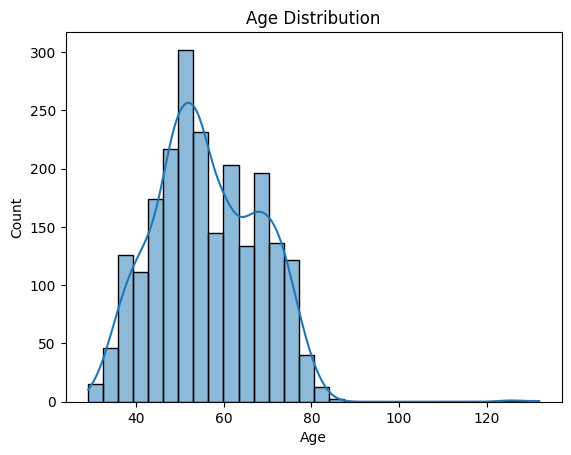

In [32]:
sns.histplot(df["Age"], bins=30, kde= True)
plt.title("Age Distribution")
plt.show()

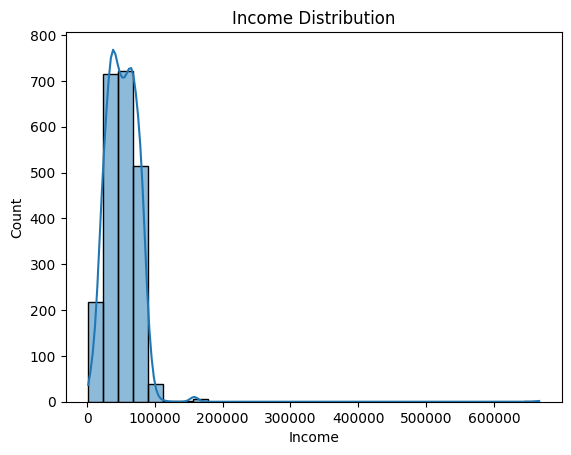

In [33]:
sns.histplot(df["Income"], bins=30, kde= True)
plt.title("Income Distribution")
plt.show()

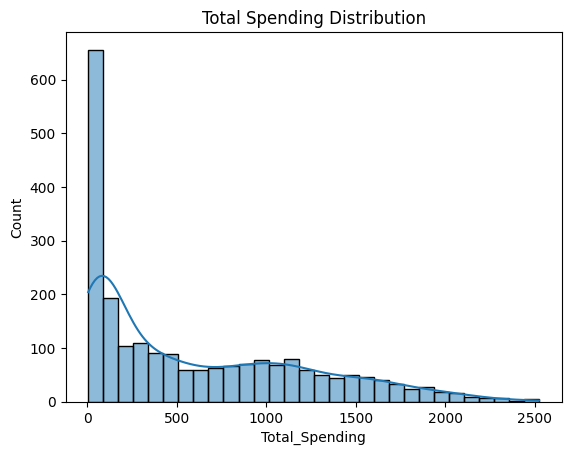

In [34]:
sns.histplot(df["Total_Spending"], bins=30, kde= True)
plt.title("Total Spending Distribution")
plt.show()

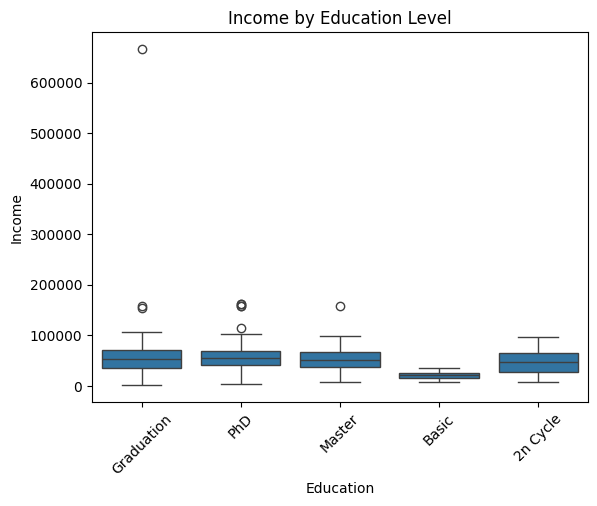

In [35]:
sns.boxplot(x="Education", y= "Income", data=df)
plt.xticks(rotation=45)
plt.title("Income by Education Level")
plt.show()

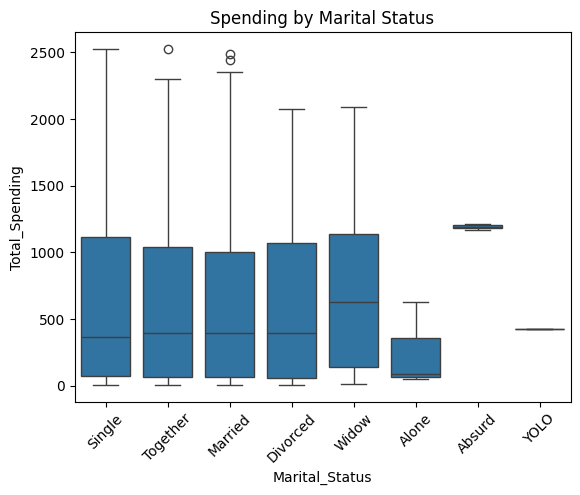

In [ ]:
sns.boxplot(x="Marital_Status", y= "Total_Spending", data=df)
plt.xticks(rotation=45)
plt.title("Spending by Marital Status")
9plt.show()

In [39]:
corr= df[["Income", "Age", "Recency", "Total_Spending", "NumWebPurchases", "NumStorePurchases"]].corr()

In [40]:
corr

,Income,Age,Recency,Total_Spending,NumWebPurchases,NumStorePurchases
Income,1.000000,0.161791,-0.003970,0.667576,0.387878,0.529362
Age,0.161791,1.000000,0.016295,0.113487,0.153051,0.127891
Recency,-0.003970,0.016295,1.000000,0.020066,-0.005641,-0.000434
Total_Spending,0.667576,0.113487,0.020066,1.000000,0.528973,0.675181
NumWebPurchases,0.387878,0.153051,-0.005641,0.528973,1.000000,0.516240
NumStorePurchases,0.529362,0.127891,-0.000434,0.675181,0.516240,1.000000


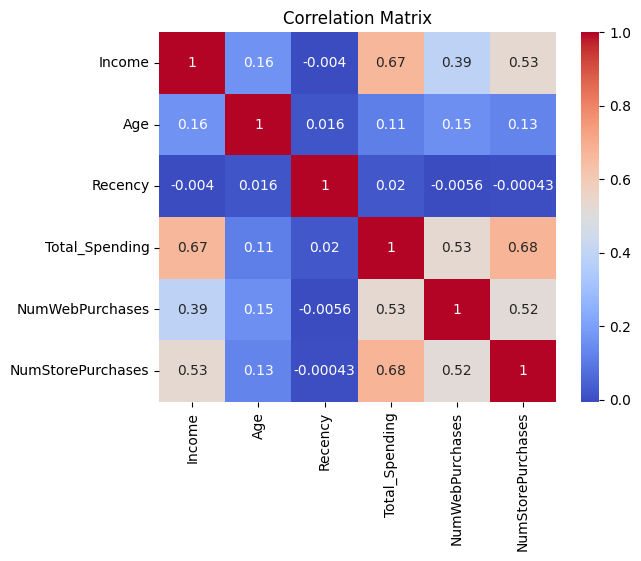

In [42]:
sns.heatmap(corr, annot= True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [44]:
pivot_income= df.pivot_table(values="Income", index= "Education", columns = "Marital_Status", aggfunc="mean")

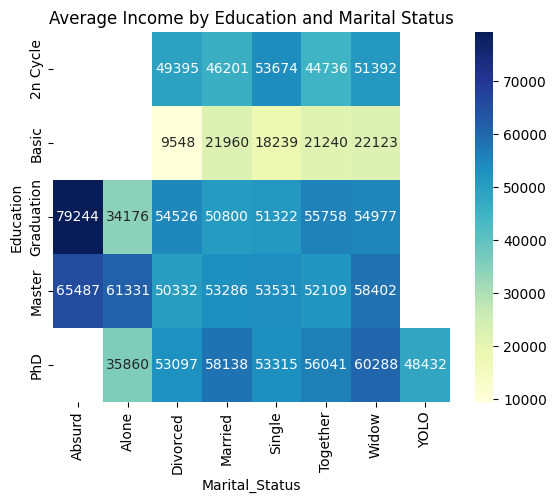

In [45]:
sns.heatmap(pivot_income, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Average Income by Education and Marital Status")
plt.show()

In [48]:
group1= df.groupby("Education")["Total_Spending"].mean().sort_values(ascending=False)
group1

Education
PhD           676.733888
Graduation    621.686380
Master        609.767123
2n Cycle      494.930000
Basic          81.796296
Name: Total_Spending, dtype: float64

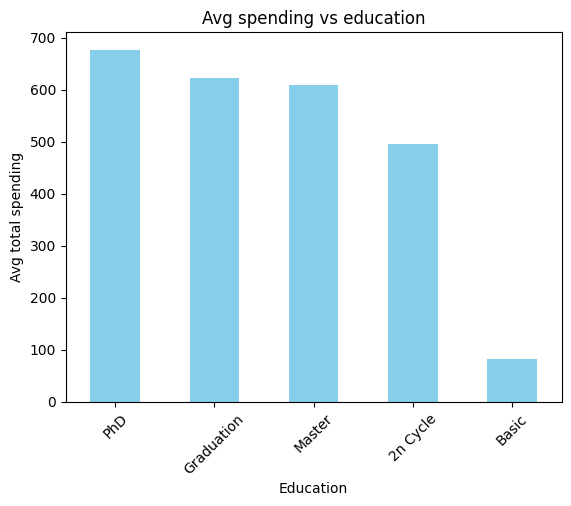

In [49]:
group1.plot(kind="bar", color="skyblue")
plt.title("Avg spending vs education")
plt.ylabel("Avg total spending")
plt.xticks(rotation=45)
plt.show()

In [51]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children', 'Total_Spending', 'Customer_Since'],
      dtype='str')

In [52]:
df["AcceptedAny"]= df[["AcceptedCmp1","AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Response"]].sum(axis=1)

In [53]:
df["AcceptedAny"].unique()

array([1, 0, 3, 2, 4, 5])

In [55]:
df["AcceptedAny"]= df["AcceptedAny"].apply(lambda x:1 if x>0 else 0)
df["AcceptedAny"].unique()

array([1, 0])

In [56]:
group2= df.groupby("Marital_Status")["AcceptedAny"].mean().sort_values(ascending=False)
group2

Marital_Status
Absurd      0.500000
YOLO        0.500000
Widow       0.342105
Alone       0.333333
Single      0.312102
Divorced    0.297414
Married     0.252042
Together    0.251309
Name: AcceptedAny, dtype: float64

AttributeError: Text.set() got an unexpected keyword argument 'rotations'

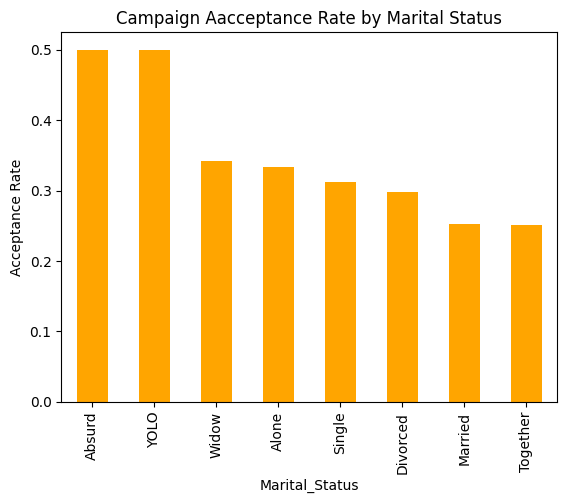

In [59]:
group2.plot(kind="bar", color = "orange")
plt.title("Campaign Aacceptance Rate by Marital Status")
plt.ylabel("Acceptance Rate")
plt.xticks(rotations=45)
plt.show()

In [61]:
bins = [18, 30 , 40, 50, 60 , 70, 90]
labels = ["18-29", "30-39", "40-49", "50-59", "60-69", "70+"]
df["AgeGroup"]=pd.cut(df["Age"], bins=bins, labels=labels)

In [62]:
df["AgeGroup"]

0       60-69
1         70+
2       50-59
3       40-49
4       40-49
        ...  
2235    50-59
2236      70+
2237    40-49
2238    60-69
2239      70+
Name: AgeGroup, Length: 2216, dtype: category
Categories (6, str): ['18-29' < '30-39' < '40-49' < '50-59' < '60-69' < '70+']

In [64]:
group3= df.groupby("AgeGroup")["Income"].mean()
group3

AgeGroup
18-29    46658.000000
30-39    46283.028302
40-49    49224.877034
50-59    50812.913303
60-69    56200.827887
70+      58944.316294
Name: Income, dtype: float64

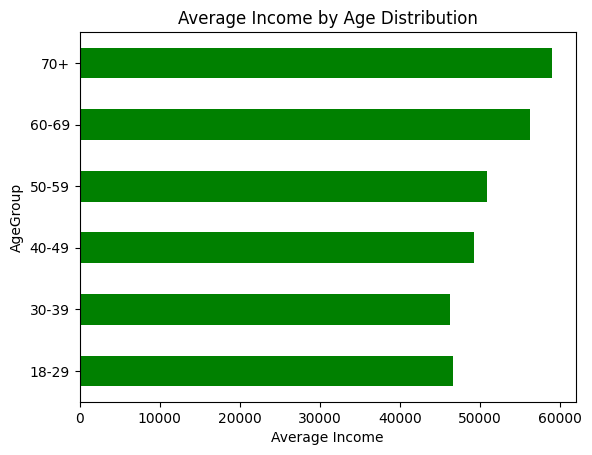

In [65]:
group3.plot(kind="barh", color ="green")
plt.title("Average Income by Age Distribution")
plt.xlabel("Average Income")
plt.show()

In [67]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children', 'Total_Spending', 'Customer_Since',
       'AcceptedAny', 'AgeGroup'],
      dtype='str')

In [68]:
## Age- income - total_spending- numwebpurchases - numstorespurchases - numwebvisitsmonth - recency

In [69]:
features= ["Age", "Income", "Total_Spending", "NumWebPurchases", "NumStorePurchases", "NumWebVisitsMonth", "Recency"]

In [70]:
X= df[features]

In [71]:
X

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
0,68,58138.0,1617,8,4,7,58
1,71,46344.0,27,1,2,5,38
2,60,71613.0,776,8,10,4,26
3,41,26646.0,53,2,4,6,26
4,44,58293.0,422,5,6,5,94
...,...,...,...,...,...,...,...
2235,58,61223.0,1341,9,4,5,46
2236,79,64014.0,444,8,5,7,56
2237,44,56981.0,1241,2,13,6,91
2238,69,69245.0,843,6,10,3,8


In [72]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [75]:
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 0.98644293,  0.2340627 ,  1.67548812, ..., -0.55414289,
         0.69323197,  0.31053212],
       [ 1.23680074, -0.23455948, -0.96235832, ..., -1.16951781,
        -0.1315745 , -0.38050944],
       [ 0.31882209,  0.76947764,  0.28024985, ...,  1.29198186,
        -0.54397773, -0.79513438],
       ...,
       [-1.01641959,  0.18809052,  1.05169551, ...,  2.21504423,
         0.28082874,  1.4507507 ],
       [ 1.06989553,  0.67538765,  0.39140438, ...,  1.29198186,
        -0.95638097, -1.41707178],
       [ 1.23680074,  0.02470453, -0.7218    , ..., -0.55414289,
         0.69323197, -0.31140528]], shape=(2216, 7))

In [76]:
from sklearn.cluster import KMeans

In [77]:
wcss=[]

In [78]:
for i in range (2, 10):
    kmeans= KMeans(n_clusters=i)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

In [80]:
wcss

[10218.620143748782,
 9007.785707340396,
 8158.811687813967,
 7699.3725566388175,
 7215.480753827621,
 6818.133800733644,
 6174.337036475022,
 6176.024820556968]

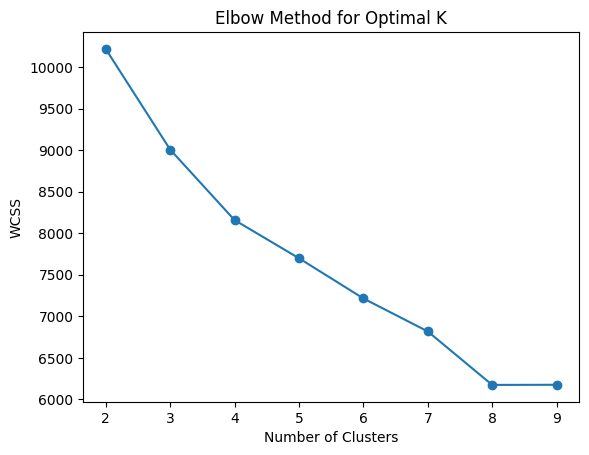

In [81]:
plt.plot(range(2,10), wcss, marker="o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [96]:
kmeans = KMeans(n_clusters=8)
df["Cluster"]= kmeans.fit_predict(X_scaled)
df["Cluster"]

0       5
1       7
2       3
3       6
4       4
       ..
2235    5
2236    1
2237    0
2238    3
2239    7
Name: Cluster, Length: 2216, dtype: int32

In [97]:
cluster_summary= df.groupby("Cluster")[features].mean()
cluster_summary

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,
0,44.186508,79477.936508,1347.250000,4.638889,8.503968,2.706349,53.710317
1,57.861423,52629.486891,558.284644,6.318352,6.108614,6.730337,31.198502
2,67.817352,73967.383562,1201.803653,4.324201,7.831050,2.593607,73.506849
3,64.214286,72347.547619,1129.861905,5.066667,9.442857,3.052381,18.361905
4,48.863248,32726.720798,113.769231,2.339031,3.205128,7.056980,77.703704
5,59.357466,63628.253394,1094.855204,8.846154,8.832579,6.144796,60.737557
6,48.586124,31099.069378,82.985646,1.887560,3.007177,6.657895,25.126794
7,68.327338,42299.352518,142.661871,2.233813,3.773381,5.327338,56.089928


In [98]:
df["Cluster"].value_counts()

Cluster
6    418
4    351
7    278
1    267
0    252
5    221
2    219
3    210
Name: count, dtype: int64

In [100]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
pca_data= pca.fit_transform(X_scaled)
df["PCA1"], df["PCA2"] = pca_data[:, 0], pca_data[:, 1]

In [103]:
df["PCA1"]

0       1.107519
1      -1.336734
2       1.882277
3      -1.784359
4       0.020363
          ...   
2235    1.248177
2236    0.508708
2237    1.153597
2238    1.887680
2239   -0.841821
Name: PCA1, Length: 2216, dtype: float64

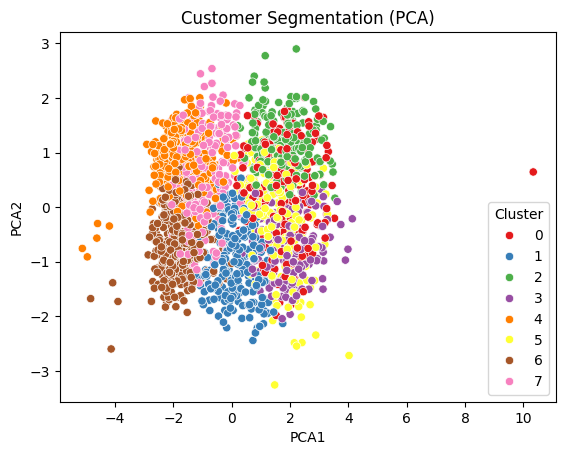

In [104]:
sns.scatterplot(x="PCA1", y="PCA2", hue="Cluster", data=df, palette = "Set1")
plt.title("Customer Segmentation (PCA)")
plt.show()

In [105]:
cluster_summary

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,
0,44.186508,79477.936508,1347.250000,4.638889,8.503968,2.706349,53.710317
1,57.861423,52629.486891,558.284644,6.318352,6.108614,6.730337,31.198502
2,67.817352,73967.383562,1201.803653,4.324201,7.831050,2.593607,73.506849
3,64.214286,72347.547619,1129.861905,5.066667,9.442857,3.052381,18.361905
4,48.863248,32726.720798,113.769231,2.339031,3.205128,7.056980,77.703704
5,59.357466,63628.253394,1094.855204,8.846154,8.832579,6.144796,60.737557
6,48.586124,31099.069378,82.985646,1.887560,3.007177,6.657895,25.126794
7,68.327338,42299.352518,142.661871,2.233813,3.773381,5.327338,56.089928


In [106]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']